In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("talk")


In [5]:
tx_df = pd.read_csv("data/Transactions.csv")
tx_new_df = tx_df.drop(columns=['oldBalanceDest', 'newBalanceDest', 'isFraud', 'isFlaggedFraud', 'isUnauthorizedOverdraft', 'isSuccessful'])

# Ensure consistent ID types
tx_new_df["idOrig"] = tx_new_df["idOrig"].astype(str)
tx_new_df["idDest"] = tx_new_df["idDest"].astype(str)

tx_df.head()

KeyError: "['oldBalanceDest', 'newBalanceDest', 'isFraud', 'isFlaggedFraud', 'isUnauthorizedOverdraft', 'isSuccessful'] not found in axis"

In [3]:
import re
tx = tx_df.copy()
tx.columns = [
        re.sub(r'[^a-zA-Z0-9_]', '', c.strip().lower().replace(' ', '_'))
        for c in tx.columns
    ]
print(tx.columns)

Index(['step', 'action', 'amount', 'idorig', 'oldbalanceorig',
       'newbalanceorig', 'iddest', 'oldbalancedest', 'newbalancedest',
       'isfraud', 'isflaggedfraud', 'isunauthorizedoverdraft', 'issuccessful'],
      dtype='str')


In [4]:
import re
def extract_transaction_scoring_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts scoring-relevant user-level features from transaction data
    for investment readiness scoring.
    """

    tx = df.copy()

    # Standardize column names
    tx.columns = [
        re.sub(r'[^a-zA-Z0-9_]', '', c.strip().lower().replace(' ', '_'))
        for c in tx.columns
    ]

    # Ensure id columns are strings
    tx["idorig"] = tx["idorig"].astype(str)
    tx["iddest"] = tx["iddest"].astype(str)

    
    # Required columns
    required_cols = [
        "step", "action", "amount", "idorig",
        "oldbalanceorig", "newbalanceorig",
        "iddest", "oldbalancedest", "newbalancedest"
    ]
    missing = [c for c in required_cols if c not in tx.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Convert numeric columns
    numeric_cols = [
        "step", "amount", "oldbalanceorig", "newbalanceorig",
        "oldbalancedest", "newbalancedest"
    ]
    for col in numeric_cols:
        tx[col] = pd.to_numeric(tx[col], errors="coerce")

    # Drop rows with essential missing data
    tx = tx.dropna(subset=["step", "amount", "idorig"])

    # --- Derived flags ---
    # Balance changes
    tx["balance_change_orig"] = tx["oldbalanceorig"] - tx["newbalanceorig"]

    # Large transactions (top 25%)
    threshold = tx["amount"].quantile(0.75)
    tx["is_large_tx"] = (tx["amount"] > threshold).astype(int)

    # Zero balance events
    tx["is_zero_balance_after"] = (tx["newbalanceorig"] <= 0).astype(int)

    # Transaction amount relative to old balance
    tx["amount_to_oldbalance_ratio"] = np.where(
        tx["oldbalanceorig"] > 0,
        tx["amount"] / tx["oldbalanceorig"],
        0
    )

    # --- Origin (sender) aggregated features ---
    origin_agg = tx.groupby("idorig").agg(
        total_transactions=("amount", "count"),
        total_amount_sent=("amount", "sum"),
        avg_amount_sent=("amount", "mean"),
        large_tx_count=("is_large_tx", "sum"),
        zero_balance_events=("is_zero_balance_after", "sum"),
        amount_to_oldbalance_ratio=("amount_to_oldbalance_ratio", "mean")
    ).reset_index()

    origin_agg["large_tx_ratio"] = origin_agg["large_tx_count"] / origin_agg["total_transactions"]
    origin_agg["zero_balance_event_ratio"] = origin_agg["zero_balance_events"] / origin_agg["total_transactions"]

    # --- Destination (receiver) aggregated features ---
    dest_agg = tx.groupby("iddest").agg(
        total_amount_received=("amount", "sum"),
        avg_amount_received=("amount", "mean")
    ).reset_index().rename(columns={"iddest": "idorig"})

    # Merge origin and destination features
    features = origin_agg.merge(dest_agg, on="idorig", how="left")
    features[["total_amount_received", "avg_amount_received"]] = features[["total_amount_received", "avg_amount_received"]].fillna(0)

    # --- Flow and ratio features ---
    features["net_transaction_flow"] = features["total_amount_received"] - features["total_amount_sent"]
    features["incoming_outgoing_amount_ratio"] = np.where(
        features["total_amount_sent"] > 0,
        features["total_amount_received"] / features["total_amount_sent"],
        0
    )

    # Unique destinations ratio
    unique_dest = tx.groupby("idorig")["iddest"].nunique().reset_index().rename(columns={"iddest": "unique_destinations"})
    features = features.merge(unique_dest, on="idorig", how="left")
    features["unique_destination_ratio"] = features["unique_destinations"] / features["total_transactions"]

    return features

In [5]:
transaction_features = extract_transaction_scoring_features(tx_df)

print(transaction_features.head())
print(transaction_features.columns.tolist())

             idorig  total_transactions  total_amount_sent  avg_amount_sent  \
0  4000306227962217                  31       1.316966e+06     42482.789355   
1  4000632439592728                 393       4.750901e+07    120888.058804   
2  4000662475538772                  54       4.280348e+06     79265.712037   
3  4001053531023588                  35       5.305200e+06    151577.133714   
4  4001059967818078                 962       1.163517e+08    120947.755333   

   large_tx_count  zero_balance_events  amount_to_oldbalance_ratio  \
0               3                    0                   21.257662   
1              96                    0                    0.059238   
2               6                    0                   13.896054   
3              12                    2                    1.443180   
4             243                    0                    1.720606   

   large_tx_ratio  zero_balance_event_ratio  total_amount_received  \
0        0.096774                 

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

# ------------------------------
# Ensure user ID is string
# ------------------------------
transaction_features["idorig"] = transaction_features["idorig"].astype(str)

# ------------------------------
# 1. Train Transaction-based scoring model
# ------------------------------
def train_transaction_model(txn_df, id_col="idorig"):
    feature_cols = [c for c in txn_df.columns if c != id_col]

    # Handle missing values
    X = txn_df[feature_cols].fillna(0)

    # Scale features
    scaler = MinMaxScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

    # Self-supervised score (same logic as CDR)
    y = X_scaled.sum(axis=1)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # Train LightGBM
    model = LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Transaction Model Evaluation:")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}\n")

    return model, scaler, feature_cols

# Train model
txn_model, txn_scaler, txn_cols = train_transaction_model(transaction_features)

# ------------------------------
# 2. Generate per-user scores + SHAP feature contributions
# ------------------------------
def score_transaction_users(txn_df, model, scaler, feature_cols, id_col="idorig"):
    X = txn_df[feature_cols].fillna(0)
    X_scaled = pd.DataFrame(scaler.transform(X), columns=feature_cols)

    # Raw model score
    txn_df["score_raw"] = model.predict(X_scaled)

    # Normalize to 0-100
    txn_df["score_normalized"] = 100 * (
        (txn_df["score_raw"] - txn_df["score_raw"].min()) /
        (txn_df["score_raw"].max() - txn_df["score_raw"].min())
    )

    # SHAP explanations
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)

    shap_df = pd.DataFrame(shap_values, columns=feature_cols)
    shap_df[id_col] = txn_df[id_col]

    # Absolute contributions → weights
    shap_df_abs = shap_df.copy()
    shap_df_abs[feature_cols] = shap_df_abs[feature_cols].abs()

    shap_weights = shap_df_abs.copy()
    shap_weights[feature_cols] = shap_weights[feature_cols].div(
        shap_weights[feature_cols].sum(axis=1), axis=0
    )

    # Convert to long format
    feature_contrib = shap_df.melt(
        id_vars=id_col,
        var_name="feature",
        value_name="contribution"
    )

    feature_weight = shap_weights.melt(
        id_vars=id_col,
        var_name="feature",
        value_name="weight"
    )

    feature_table = feature_contrib.merge(
        feature_weight, on=[id_col, "feature"]
    )

    feature_table = feature_table.merge(
        txn_df[[id_col, "score_normalized"]],
        on=id_col
    )

    return txn_df[[id_col, "score_raw", "score_normalized"]], feature_table


# Generate scores
txn_scores, txn_feature_table = score_transaction_users(
    transaction_features,
    txn_model,
    txn_scaler,
    txn_cols
)

# ------------------------------
# 3. Save results
# ------------------------------
txn_scores.to_csv("transaction_user_scores.csv", index=False)
txn_feature_table.to_csv("transaction_user_feature_scores.csv", index=False)

print("Transaction-based scoring complete. Results saved.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3117
[LightGBM] [Info] Number of data points in the train set: 3209, number of used features: 14
[LightGBM] [Info] Start training from score 2.043477
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [8]:
import joblib
joblib.dump({
    "model": txn_model,
    "scaler": txn_scaler,
    "feature_cols": txn_cols
}, "transaction_model.joblib")

['transaction_model.joblib']

In [7]:
tx_new_df.head()

,step,action,amount,idOrig,oldBalanceOrig,newBalanceOrig,idDest
0,0,PAYMENT,545.85,4101104208275644,182604.85,182059.00,02-0009251
1,0,TRANSFER,17190.81,4101104208275644,182059.00,164868.19,4046522631502888
2,0,PAYMENT,596.42,4842523936281596,177448.67,176852.25,73-0005075
3,0,TRANSFER,17160.96,4842523936281596,176852.25,159691.29,4551500766064798
4,0,PAYMENT,700.80,4925607696779699,14817.64,14116.85,64-0004955


In [28]:
# Ensure consistent ID types
tx_new_df["idOrig"] = tx_new_df["idOrig"].astype(str)
tx_new_df["idDest"] = tx_new_df["idDest"].astype(str)


In [ ]:
'''
1. Descriptive Statistics Computation
    Compute summary statistics (mean, median, minimum, maximum, and standard deviation) 
    for numerical attributes such as transaction amounts and account balances.
2. Categorical Distribution Analysis
    Analyze transaction type distributions to validate 
    realistic usage patterns across different mobile money services.
3. Transaction Frequency per User
    Aggregate total transaction participation per user 
    to assess engagement levels and identify high-activity and low-activity users.
4. Transaction Frequency by Type
    Analyze per-user transaction frequency grouped by transaction type to capture behavioral diversity.
5. Outlier Detection
    Identify extreme values in transaction amounts, balances, and 
    transaction frequency to understand tail behavior and potential anomalies.
6. Visualization and Pattern Exploration
    Use histograms, boxplots, and bar charts to visually examine distributions, skewness, and behavioral patterns in the data.
'''

In [29]:
# Select numerical columns
numeric_cols = [
    "amount",
    "oldBalanceOrig",
    "newBalanceOrig"
]

# Summary statistics
tx_new_df[numeric_cols].describe()


,amount,oldBalanceOrig,newBalanceOrig
count,8.161520e+05,8.161520e+05,8.161520e+05
mean,1.217977e+05,3.186520e+06,3.171797e+06
std,2.717763e+05,1.890622e+06,1.858686e+06
min,1.000000e-02,-1.961808e+05,-1.961808e+05
25%,1.023451e+04,2.294069e+06,2.299226e+06
50%,6.702873e+04,3.298404e+06,3.285199e+06
75%,1.541123e+05,4.078261e+06,4.052179e+06
max,5.000000e+06,3.786901e+07,3.687497e+07


In [31]:
# Transaction type distribution
tx_type_distribution = (
    tx_new_df["action"]
    .value_counts()
    .reset_index()
)

tx_type_distribution


,action,count
0,CASH_IN,292422
1,PAYMENT,217763
2,CASH_OUT,162414
3,TRANSFER,96585
4,DEBIT,46968


In [32]:
# Ensure consistent ID types
tx_new_df["idOrig"] = tx_new_df["idOrig"].astype(str)
tx_new_df["idDest"] = tx_new_df["idDest"].astype(str)

# Combine all user participations
all_users = pd.concat([
    tx_new_df["idOrig"],
    tx_new_df["idDest"]
])

# Total transactions per user
tx_frequency = (
    all_users
    .value_counts()
    .reset_index()
    .rename(columns={
        "index": "user_id",
        0: "total_tx_count"
    })
)

tx_frequency.head()


,user_id,count
0,4803231842294193,80490
1,B12-0008842,38280
2,4435340316518106,1512
3,65-0006323,1492
4,54-0008965,1484


In [33]:
# Build user–transaction type participation table
user_tx_type = pd.concat([
    tx_new_df[["idOrig", "action"]].rename(columns={"idOrig": "user_id"}),
    tx_new_df[["idDest", "action"]].rename(columns={"idDest": "user_id"})
])

# Group by user and transaction type
tx_type_per_user = (
    user_tx_type
    .groupby(["user_id", "action"])
    .size()
    .reset_index(name="tx_count")
)

tx_type_per_user.head()


,user_id,action,tx_count
0,00-0000439,CASH_IN,407
1,00-0000439,CASH_OUT,267
2,00-0000439,PAYMENT,338
3,00-0003792,CASH_IN,511
4,00-0003792,CASH_OUT,281


In [37]:
Q1 = tx_new_df["amount"].quantile(0.25)
Q3 = tx_new_df["amount"].quantile(0.75)
IQR = Q3 - Q1

amount_outliers = tx_new_df[
    (tx_new_df["amount"] < Q1 - 1.5 * IQR) |
    (tx_new_df["amount"] > Q3 + 1.5 * IQR)
]

amount_outliers.describe()


,step,amount,oldBalanceOrig,newBalanceOrig
count,29179.000000,2.917900e+04,2.917900e+04,2.917900e+04
mean,207.003084,1.139035e+06,3.973942e+06,3.045517e+06
std,108.181591,8.958933e+05,2.075022e+06,1.943181e+06
min,1.000000,3.699392e+05,-1.404377e+05,-1.916106e+05
25%,142.000000,5.392711e+05,3.094132e+06,2.009802e+06
50%,212.000000,8.162937e+05,3.837999e+06,2.937839e+06
75%,285.000000,1.398947e+06,4.646615e+06,3.820680e+06
max,717.000000,5.000000e+06,3.786901e+07,3.687497e+07


In [18]:
tx_frequency.describe()

,count
count,4799.000000
mean,340.134195
std,1330.477355
min,1.000000
25%,64.000000
50%,168.000000
75%,372.000000
max,80490.000000


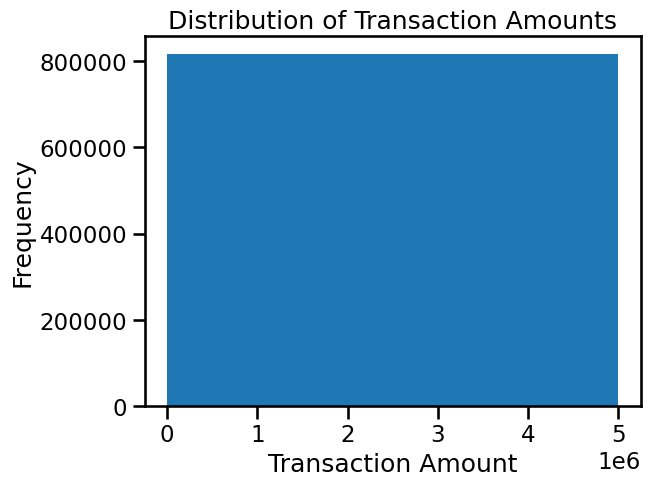

In [42]:
# Transaction Amount Distribution
plt.figure()
plt.hist(tx_new_df["amount"], bins=1)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amounts")
plt.show()


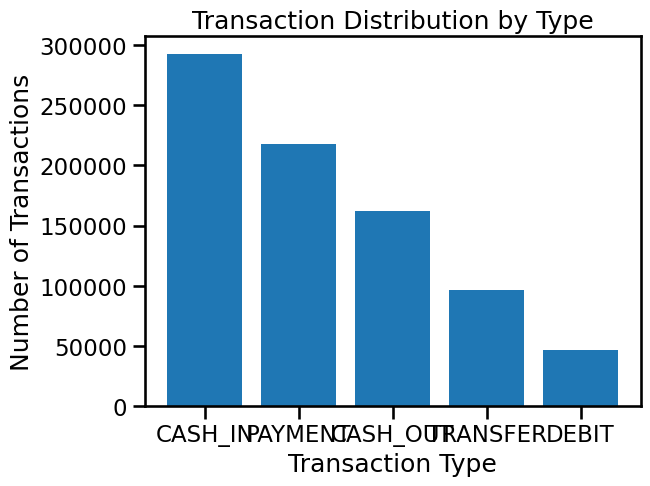

In [36]:
# Transaction Type Distribution
plt.figure()
plt.bar(
    tx_type_distribution["action"],
    tx_type_distribution["count"]
)
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.title("Transaction Distribution by Type")
plt.show()


In [25]:
plt.figure()
plt.hist(tx_frequency["total_tx_count"], bins=50)
plt.xlabel("Total Transactions per User")
plt.ylabel("Number of Users")
plt.title("Transaction Frequency per User")
plt.show()


KeyError: 'total_tx_count'

<Figure size 640x480 with 0 Axes>

In [ ]:
# Combine originators and recipients
user_tx_type = pd.concat([
    tx_new_df[["idOrig", "action"]].rename(columns={"idOrig": "user_id"}),
    tx_new_df[["idDest", "action"]].rename(columns={"idDest": "user_id"})
])

# Group by user and transaction type
tx_type_per_user = (
    user_tx_type
    .groupby(["user_id", "action"])
    .size()
    .reset_index(name="tx_count")
)

# Aggregate stats per transaction type
tx_type_stats = (
    tx_type_per_user
    .groupby("action")["tx_count"]
    .agg(['min', 'mean', 'max'])
    .reset_index()
)

# Optional: round mean for readability
tx_type_stats['mean'] = tx_type_stats['mean'].round(2)

tx_type_stats

In [51]:
# Transactions per user
tx_per_user = tx_new_df.groupby('idOrig').size().reset_index(name='tx_count')


In [52]:
summary_stats = tx_per_user['tx_count'].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
).to_frame(name='Transaction Frequency')

summary_stats


,Transaction Frequency
count,4012.000000
mean,203.427717
std,1275.780906
min,1.000000
10%,14.000000
25%,48.000000
50%,121.000000
75%,260.000000
90%,383.700000
99%,903.780000


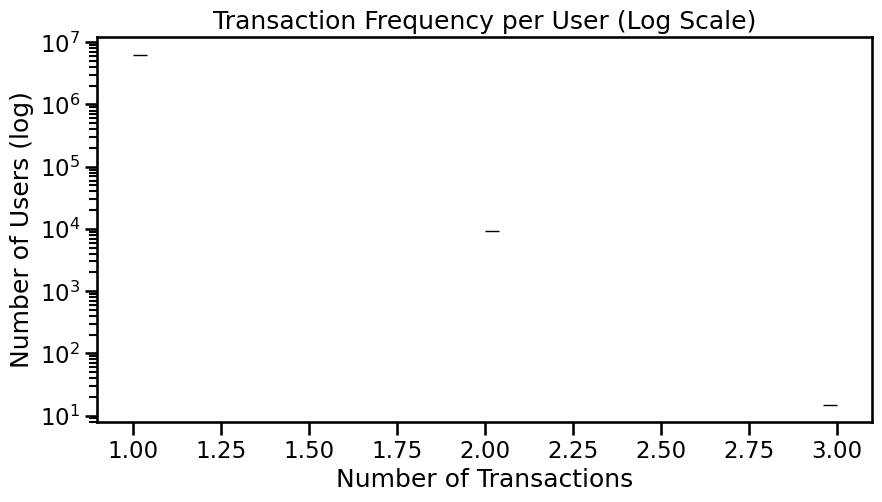

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(tx_per_user['tx_count'], bins=50, log_scale=(False, True))
plt.title('Transaction Frequency per User (Log Scale)')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Users (log)')
plt.show()

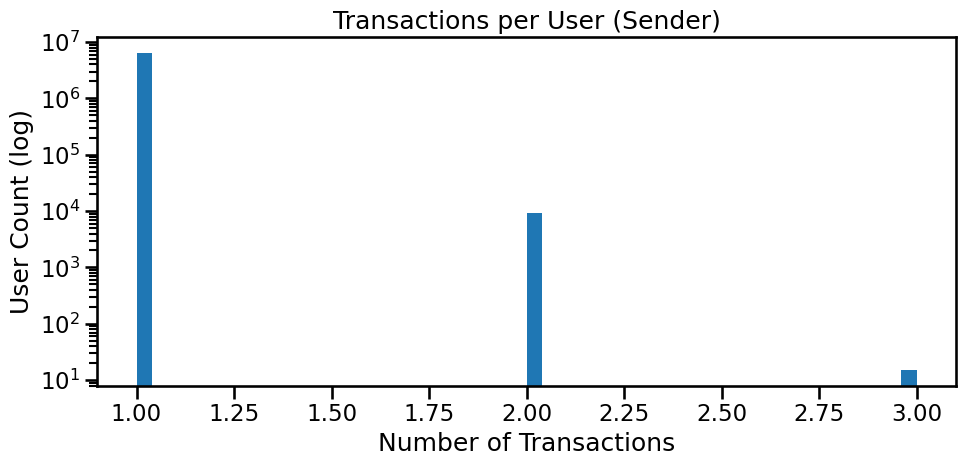

In [9]:
# Transaction Per User, Sender Activity

tx_per_user = tx_df.groupby("nameOrig").size()
plt.figure(figsize=(10,5))
plt.hist(tx_per_user, bins=50, log=True)
plt.title("Transactions per User (Sender)")
plt.xlabel("Number of Transactions")
plt.ylabel("User Count (log)")
plt.tight_layout()
plt.show()


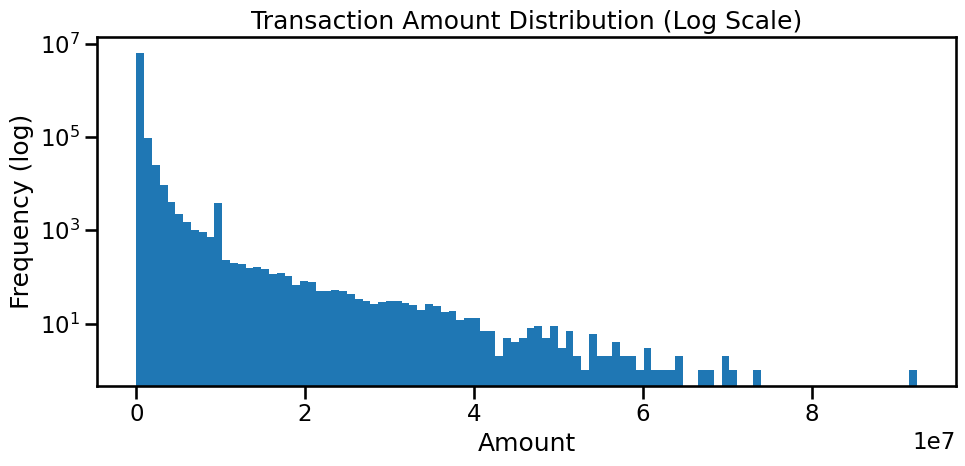

In [11]:
# Transaction Value Analysis

tx_df["amount"].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,0.99])
plt.figure(figsize=(10,5))
plt.hist(tx_df["amount"], bins=100)
plt.yscale("log")
plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("Amount")
plt.ylabel("Frequency (log)")
plt.tight_layout()
plt.show()


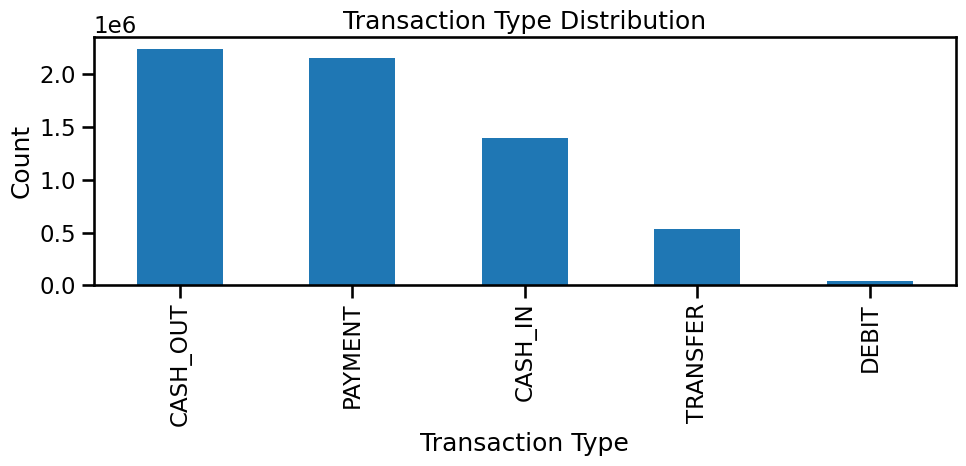

In [12]:
# Transaction Type Analysis

type_counts = tx_df["type"].value_counts()
type_pct = type_counts / type_counts.sum() * 100

type_pct

plt.figure(figsize=(10,5))
type_counts.plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



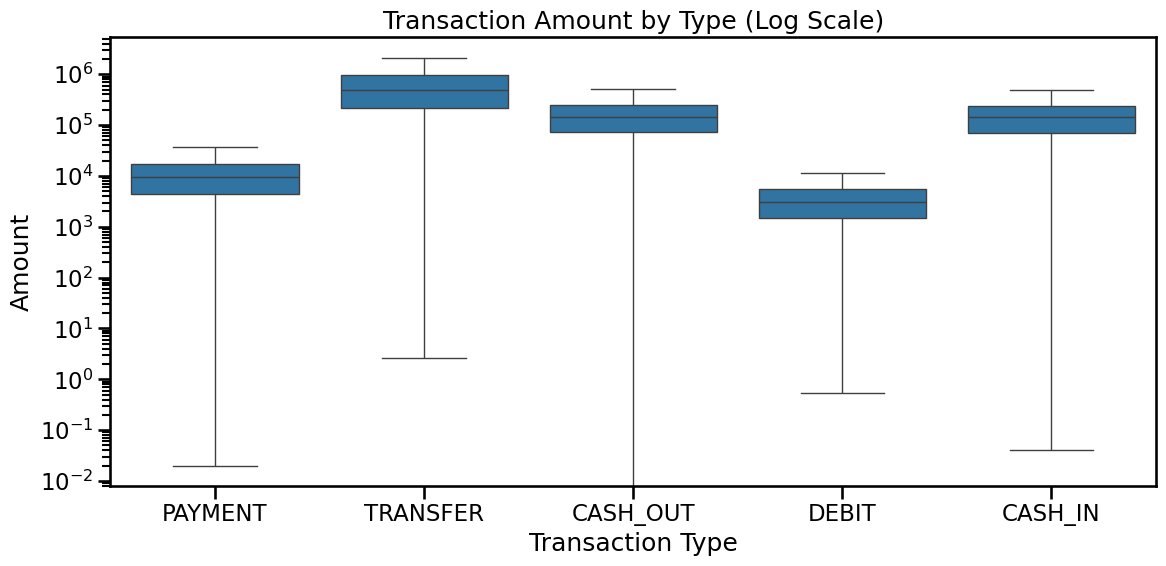

In [13]:
# Amount by Transaction Type

plt.figure(figsize=(12,6))
sns.boxplot(
    data=tx_df,
    x="type",
    y="amount",
    showfliers=False
)
plt.yscale("log")
plt.title("Transaction Amount by Type (Log Scale)")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()


---
## Train Production Model on MoMTSim Dataset

The cells below train the **transaction scoring model** that InvestorLens uses in production.  
They load the MoMTSim synthetic dataset (~1.7 M rows), engineer the same features as `ml.py`, train a LightGBM regressor, and save the bundle to `investor-lens-backend/models/transaction_model.joblib`.

Run these four cells once (or whenever you want to retrain with fresh data).

In [1]:
import re
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()          # Notebooks/
DATA_FILE    = NOTEBOOK_DIR / 'data' / 'MoMTSim_20260516103214_1000_rawLog.csv'
OUTPUT_PATH  = NOTEBOOK_DIR.parent / 'investor-lens-backend' / 'models' / 'transaction_model.joblib'

if not DATA_FILE.exists():
    raise FileNotFoundError(f'Data file not found: {DATA_FILE}')

# 13 columns, no header
COLUMN_NAMES = [
    'step', 'action', 'amount',
    'nameOrig', 'oldBalanceOrig', 'newBalanceOrig',
    'nameDest',  'oldBalanceDest',  'newBalanceDest',
    'isFraud', 'isFlaggedFraud', 'isUnauthorizedOverdraft', 'isSuccessful',
]

print(f'Loading {DATA_FILE} ...')
momsim_df = pd.read_csv(DATA_FILE, header=None, names=COLUMN_NAMES)
print(f'  {len(momsim_df):,} rows | {momsim_df["nameOrig"].nunique():,} unique senders')
momsim_df.head(3)

Loading /Users/newton/Strathmore/Project_App/Notebooks/data/MoMTSim_20260516103214_1000_rawLog.csv ...
  1,713,977 rows | 9,999 unique senders


,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud,isUnauthorizedOverdraft,isSuccessful
0,0,PAYMENT,628.92,4514626790441516,7.72,-621.20,56-0008259,0.0,628.92,0,0,0,1
1,0,TRANSFER,17298.25,4514626790441516,-621.20,-17919.45,4381946196452028,82.0,17380.25,1,0,0,1
2,0,PAYMENT,570.66,4948645360479371,47797.14,47226.47,11-0009026,0.0,570.66,0,0,0,1


In [2]:
# ── Normalise column names (same regex as ml.py) ─────────────────────────────
momsim_df.columns = [
    re.sub(r'[^a-zA-Z0-9_]', '', c.strip().lower().replace(' ', '_'))
    for c in momsim_df.columns
]

# MoMTSim uses nameOrig/nameDest → remap to internal idorig/iddest
momsim_df = momsim_df.rename(columns={'nameorig': 'idorig', 'namedest': 'iddest'})
momsim_df['idorig'] = momsim_df['idorig'].astype(str)
momsim_df['iddest'] = momsim_df['iddest'].astype(str)

# Numeric coercion & drop bad rows
for col in ['step', 'amount', 'oldbalanceorig', 'newbalanceorig', 'oldbalancedest', 'newbalancedest']:
    momsim_df[col] = pd.to_numeric(momsim_df[col], errors='coerce')
momsim_df = momsim_df.dropna(subset=['step', 'amount', 'idorig'])

# ── Feature engineering (mirrors engineer_transaction_features in ml.py) ──────
threshold = momsim_df['amount'].quantile(0.75)
momsim_df['is_large_tx']           = (momsim_df['amount'] > threshold).astype(int)
momsim_df['is_zero_balance_after']  = (momsim_df['newbalanceorig'] <= 0).astype(int)
momsim_df['amount_to_oldbalance_ratio'] = np.where(
    momsim_df['oldbalanceorig'] > 0,
    momsim_df['amount'] / momsim_df['oldbalanceorig'], 0)

origin = momsim_df.groupby('idorig').agg(
    total_transactions         = ('amount', 'count'),
    total_amount_sent          = ('amount', 'sum'),
    avg_amount_sent            = ('amount', 'mean'),
    large_tx_count             = ('is_large_tx', 'sum'),
    zero_balance_events        = ('is_zero_balance_after', 'sum'),
    amount_to_oldbalance_ratio = ('amount_to_oldbalance_ratio', 'mean'),
).reset_index()
origin['large_tx_ratio']           = origin['large_tx_count']      / origin['total_transactions']
origin['zero_balance_event_ratio'] = origin['zero_balance_events'] / origin['total_transactions']

dest = momsim_df.groupby('iddest').agg(
    total_amount_received = ('amount', 'sum'),
    avg_amount_received   = ('amount', 'mean'),
).reset_index().rename(columns={'iddest': 'idorig'})

momsim_features = origin.merge(dest, on='idorig', how='left')
momsim_features[['total_amount_received', 'avg_amount_received']] = (
    momsim_features[['total_amount_received', 'avg_amount_received']].fillna(0))

momsim_features['net_transaction_flow'] = (
    momsim_features['total_amount_received'] - momsim_features['total_amount_sent'])
momsim_features['incoming_outgoing_amount_ratio'] = np.where(
    momsim_features['total_amount_sent'] > 0,
    momsim_features['total_amount_received'] / momsim_features['total_amount_sent'], 0)

unique_dest = (
    momsim_df.groupby('idorig')['iddest'].nunique()
      .reset_index()
      .rename(columns={'iddest': 'unique_destinations'})
)
momsim_features = momsim_features.merge(unique_dest, on='idorig', how='left')
momsim_features['unique_destination_ratio'] = (
    momsim_features['unique_destinations'] / momsim_features['total_transactions'])

print(f'Feature matrix: {momsim_features.shape[0]:,} users x {momsim_features.shape[1]-1} features')
momsim_features.head(3)

Feature matrix: 9,999 users x 14 features


,idorig,total_transactions,total_amount_sent,avg_amount_sent,large_tx_count,zero_balance_events,amount_to_oldbalance_ratio,large_tx_ratio,zero_balance_event_ratio,total_amount_received,avg_amount_received,net_transaction_flow,incoming_outgoing_amount_ratio,unique_destinations,unique_destination_ratio
0,4000117101484909,104,13630018.79,131057.872981,22,0,5.176691,0.211538,0.000000,3686769.75,4.608462e+05,-9943249.04,0.270489,41,0.394231
1,4000169560762986,76,17962709.15,236351.436184,21,0,0.260249,0.276316,0.000000,5763611.26,1.152722e+06,-12199097.89,0.320865,19,0.250000
2,4000214180691577,79,10072200.76,127496.212152,18,1,5.337124,0.227848,0.012658,8708979.15,5.805986e+05,-1363221.61,0.864655,20,0.253165


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# ── Feature matrix ────────────────────────────────────────────────────────────
feature_cols = [c for c in momsim_features.columns if c != 'idorig']
X = momsim_features[feature_cols].fillna(0)

# Log1p-transform absolute amount columns so the MinMaxScaler is scale-invariant.
# Without this, demo data with small amounts ($200) maps to ~0 after scaling
# against MoMTSim amounts ($140k average), producing near-zero scores.
# log1p($200)=5.3 vs log1p($140k)=11.8 — ratio shrinks from 700x to 2.2x.
LOG_FEATURES = [
    'total_amount_sent', 'avg_amount_sent',
    'total_amount_received', 'avg_amount_received',
    'net_transaction_flow',
]
for col in LOG_FEATURES:
    if col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

# ── Scale & train ─────────────────────────────────────────────────────────────
scaler   = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

y = X_scaled.sum(axis=1)   # self-supervised target

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'RMSE : {float(np.sqrt(mean_squared_error(y_test, y_pred))):.4f}')
print(f'MAE  : {float(mean_absolute_error(y_test, y_pred)):.4f}')
print(f'R2   : {float(r2_score(y_test, y_pred)):.4f}')
print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'Log-transformed: {LOG_FEATURES}')

RMSE : 0.0323
MAE  : 0.0210
R2   : 0.9976
Features (14): ['total_transactions', 'total_amount_sent', 'avg_amount_sent', 'large_tx_count', 'zero_balance_events', 'amount_to_oldbalance_ratio', 'large_tx_ratio', 'zero_balance_event_ratio', 'total_amount_received', 'avg_amount_received', 'net_transaction_flow', 'incoming_outgoing_amount_ratio', 'unique_destinations', 'unique_destination_ratio']
Log-transformed: ['total_amount_sent', 'avg_amount_sent', 'total_amount_received', 'avg_amount_received', 'net_transaction_flow']


In [4]:
# ── Save bundle to backend models folder ──────────────────────────────────────
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    'model': model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'log_features': LOG_FEATURES,   # stored so inference applies the same transform
}, OUTPUT_PATH)
print(f'Saved to {OUTPUT_PATH}')
print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'Log-transformed: {LOG_FEATURES}')

Saved to /Users/newton/Strathmore/Project_App/investor-lens-backend/models/transaction_model.joblib
Features (14): ['total_transactions', 'total_amount_sent', 'avg_amount_sent', 'large_tx_count', 'zero_balance_events', 'amount_to_oldbalance_ratio', 'large_tx_ratio', 'zero_balance_event_ratio', 'total_amount_received', 'avg_amount_received', 'net_transaction_flow', 'incoming_outgoing_amount_ratio', 'unique_destinations', 'unique_destination_ratio']
Log-transformed: ['total_amount_sent', 'avg_amount_sent', 'total_amount_received', 'avg_amount_received', 'net_transaction_flow']
